# Shapflow with Data-Driven Graph Construction

Adapting shapflow.flow to work with discovered causal structures by using **empirical conditional distributions** instead of theoretical functions.

**Key Insight from Tutorial:**
- Source nodes (no parents): Just names, no functions needed
- Intermediate nodes (with parents): Need functions - we'll use data-driven sampling
- Target node (Y): Use the ML model

This bridges the gap between the tutorial (known mechanisms) and our case (discovered structure only).

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import sys

# Add shapflow to path if needed
shapflow_path = Path.cwd() / 'shapflow'  # Adjust if shapflow is elsewhere
if shapflow_path.exists() and str(shapflow_path) not in sys.path:
    sys.path.insert(0, str(shapflow_path))

from shapflow.flow import Node, Graph, GraphExplainer
from predictive_models.predictive_models import LGBMRegressor

print("✅ Imports successful")

✅ Imports successful


## 1. Load Data and Model

In [2]:
# Dataset configuration
dataset_name = "mixed_no_conf_f50_s1000_p50"
method_name = "lingam"  # or 'lingam'

# Load data
train_data = pd.read_parquet(f"data/processed/{dataset_name}_train.parquet")
test_data = pd.read_parquet(f"data/processed/{dataset_name}_test.parquet")

X_train = train_data.drop('Y', axis=1)
y_train = train_data['Y']
X_test = test_data.drop('Y', axis=1)
y_test = test_data['Y']

# Load model
model = LGBMRegressor.load(f"models/{dataset_name}_lgbm")

print(f"Data: {X_train.shape}, Model features: {len(model.selected_features)}")

LightGBM model loaded from models/mixed_no_conf_f50_s1000_p50_lgbm.pkl
Data: (800, 50), Model features: 50


In [3]:
train_data["Y"].describe()

count    800.000000
mean       0.014874
std        1.100613
min       -7.638759
25%       -0.475177
50%       -0.034988
75%        0.417622
max        7.271624
Name: Y, dtype: float64

In [4]:
# Load causal structure
# adjacency_matrix = np.load(f"data/causal/{dataset_name}_{method_name}_train_adjacency.npy")
import json
results_path = f"data/causal/{dataset_name}_{method_name}_results.json"
with open(results_path, 'r') as f:
    results_json = json.load(f)
adjacency_matrix = np.array(results_json['adjacency_matrix'])
n_features = adjacency_matrix.shape[0]

print(f"Causal structure: {adjacency_matrix.shape}")
print(f"Edges: {np.sum(adjacency_matrix != 0)}")

Causal structure: (51, 51)
Edges: 238


In [5]:
feature_names = results_json["feature_names"]

## 2. Build Data-Driven Conditional Samplers

Since we don't know the true causal functions, we'll create empirical samplers that learn from data.

### Filter Adjacency Matrix to Y-Reachable Nodes

Before creating the Graph, filter the adjacency matrix by **zeroing out edges** that don't contribute to reaching target Y.

**Key Idea:** 
- Use backward BFS from Y to identify reachable nodes
- Zero out edges that are NOT between reachable nodes
- **Keep the same matrix size** and feature order for data compatibility

This approach maintains compatibility with existing data while reducing computational cost by preventing GraphExplainer from learning causal functions for irrelevant edges.

In [6]:
def filter_adjacency_to_sink_reachable(adjacency_matrix, feature_names, sink_name='Y'):
    """
    Filter adjacency matrix by zeroing out edges that don't contribute to reaching the sink node.
    
    Uses BACKWARD BFS from sink (same logic as ShapleyFlowWrapper and visualization):
    1. Start from sink node (Y)
    2. Walk backward through parents
    3. Identify all nodes reachable from sink
    4. Zero out edges that are NOT between reachable nodes
    
    This ensures GraphExplainer only computes causal functions for paths that
    actually contribute to predicting Y, while maintaining the same matrix size
    and feature order for compatibility with data and models.
    
    Parameters:
    -----------
    adjacency_matrix : np.ndarray
        Original adjacency matrix (n_features × n_features) where adj[i,j]=1 means i→j
        Should include Y as a node
    feature_names : list
        List of all feature names INCLUDING Y (e.g., ['X0', 'X1', ..., 'Y'])
    sink_name : str, default='Y'
        Name of the sink/target node
    
    Returns:
    --------
    filtered_adjacency : np.ndarray
        Filtered adjacency matrix (SAME SIZE as input, but with irrelevant edges zeroed)
    feature_names : list
        Same feature names as input (unchanged, for consistency)
    reachable_indices : list
        Indices of nodes that can reach the sink
    stats : dict
        Statistics about filtering (nodes kept, edges kept, etc.)
    
    Examples:
    --------
    >>> # Original adjacency: 51×51 (50 features + Y)
    >>> adj_filtered, features, indices, stats = filter_adjacency_to_sink_reachable(
    ...     adjacency_matrix=adjacency_matrix,
    ...     feature_names=feature_names,
    ...     sink_name='Y'
    ... )
    >>> # Filtered adjacency: still 51×51, but irrelevant edges are 0
    >>> # Can use with same train_data columns!
    >>> graph = adjacency_to_graph(adj_filtered, features, train_data)
    """
    
    # Validate inputs
    n_features = adjacency_matrix.shape[0]
    if len(feature_names) != n_features:
        raise ValueError(f"feature_names length ({len(feature_names)}) must match "
                        f"adjacency_matrix size ({n_features})")
    
    if sink_name not in feature_names:
        raise ValueError(f"sink_name '{sink_name}' not found in feature_names")
    
    sink_idx = feature_names.index(sink_name)
    
    # Build parent dictionary from adjacency matrix
    parents = {}
    for j in range(n_features):
        parents[j] = [i for i in range(n_features) if adjacency_matrix[i, j] != 0]
    
    # BACKWARD BFS FROM SINK - find all nodes that can reach the sink
    # (Same logic as ShapleyFlowWrapper and visualize_causal_graph_filtered_to_sink)
    reachable_indices = set()
    queue = [sink_idx]
    visited = {sink_idx}
    
    while queue:
        current_idx = queue.pop(0)
        reachable_indices.add(current_idx)
        
        # Add all parents (predecessors) of current node
        for parent_idx in parents.get(current_idx, []):
            if parent_idx not in visited:
                visited.add(parent_idx)
                queue.append(parent_idx)
    
    # Create filtered adjacency matrix (SAME SIZE as original)
    # Copy the original, then zero out edges NOT between reachable nodes
    filtered_adjacency = adjacency_matrix.copy()
    
    reachable_set = set(reachable_indices)
    
    for i in range(n_features):
        for j in range(n_features):
            # If either node is not reachable from Y, zero out the edge
            if i not in reachable_set or j not in reachable_set:
                filtered_adjacency[i, j] = 0
    
    # Calculate statistics
    n_total_edges = int(np.sum(adjacency_matrix != 0))
    n_filtered_edges = int(np.sum(filtered_adjacency != 0))
    n_reachable = len(reachable_indices)
    n_filtered_out_nodes = n_features - n_reachable
    n_filtered_out_edges = n_total_edges - n_filtered_edges
    
    # Identify real source nodes (no parents AND can reach sink)
    potential_sources = [i for i in range(n_features) if len(parents[i]) == 0]
    real_source_indices = [s for s in potential_sources if s in reachable_set]
    
    stats = {
        'total_nodes': n_features,
        'nodes_kept': n_reachable,
        'nodes_filtered': n_filtered_out_nodes,
        'total_edges': n_total_edges,
        'edges_kept': n_filtered_edges,
        'edges_filtered': n_filtered_out_edges,
        'potential_sources': len(potential_sources),
        'real_sources': len(real_source_indices),
        'filtered_sources': len(potential_sources) - len(real_source_indices),
        'percentage_nodes_kept': 100 * n_reachable / n_features,
        'percentage_edges_kept': 100 * n_filtered_edges / max(1, n_total_edges)
    }
    
    # Print summary
    print(f"\n{'='*70}")
    print(f"ADJACENCY MATRIX FILTERING - ZERO OUT NON-Y-REACHABLE EDGES")
    print(f"{'='*70}")
    print(f"Sink node: {sink_name}")
    print(f"\n📊 Matrix Size:")
    print(f"   Input adjacency: {adjacency_matrix.shape}")
    print(f"   Output adjacency: {filtered_adjacency.shape} (SAME SIZE)")
    print(f"   Feature names: {len(feature_names)} (UNCHANGED)")
    
    print(f"\n📊 Nodes:")
    print(f"   Total nodes: {stats['total_nodes']}")
    print(f"   Nodes reachable to {sink_name}: {stats['nodes_kept']} ({stats['percentage_nodes_kept']:.1f}%)")
    print(f"   Nodes NOT reachable (will have all edges zeroed): {stats['nodes_filtered']}")
    
    print(f"\n📊 Edges:")
    print(f"   Total edges: {stats['total_edges']}")
    print(f"   Edges kept (between reachable nodes): {stats['edges_kept']} ({stats['percentage_edges_kept']:.1f}%)")
    print(f"   Edges zeroed out: {stats['edges_filtered']}")
    
    print(f"\n📊 Source Nodes:")
    print(f"   Potential sources (no parents): {stats['potential_sources']}")
    print(f"   Real sources (can reach {sink_name}): {stats['real_sources']}")
    print(f"   Filtered sources (disconnected): {stats['filtered_sources']}")
    
    if n_filtered_out_nodes > 0:
        filtered_out_names = [feature_names[i] for i in range(n_features) if i not in reachable_set]
        print(f"\n⚠️  Nodes with all edges zeroed ({n_filtered_out_nodes}):")
        print(f"   {', '.join(filtered_out_names[:10])}")
        if len(filtered_out_names) > 10:
            print(f"   ... and {len(filtered_out_names) - 10} more")
    
    print(f"\n✅ Filtered adjacency matrix: {filtered_adjacency.shape}")
    print(f"   Same size and feature order as input - compatible with data!")
    print(f"   GraphExplainer will skip {stats['edges_filtered']} irrelevant edges")
    print(f"{'='*70}\n")
    
    # Return same feature_names (unchanged) for compatibility
    return filtered_adjacency, feature_names, sorted(list(reachable_indices)), stats

print("✅ Adjacency filtering function created")

✅ Adjacency filtering function created


### Apply Filtering to Current Dataset

The adjacency matrix and feature names already include Y. Let's apply backward BFS filtering to **zero out edges** that don't reach Y, while keeping the matrix size unchanged:

In [7]:
# The adjacency_matrix and feature_names already include Y at the last position
# No need to add Y again - just use them directly

print(f"📊 Original adjacency matrix (includes Y):")
print(f"   Shape: {adjacency_matrix.shape}")
print(f"   Features: {len(feature_names)}")
print(f"   Total edges: {int(np.sum(adjacency_matrix != 0))}")

# Check if Y is in feature_names
if 'Y' in feature_names:
    y_idx = feature_names.index('Y')
    n_parents_y = int(np.sum(adjacency_matrix[:, y_idx] != 0))
    print(f"   Y is at index: {y_idx}")
    print(f"   Direct parents of Y: {n_parents_y}")
    
    # Show which features are direct parents of Y
    parent_indices = np.where(adjacency_matrix[:, y_idx] != 0)[0]
    if len(parent_indices) > 0:
        parent_names = [feature_names[i] for i in parent_indices]
        print(f"   Y's parents: {', '.join(parent_names[:10])}")
        if len(parent_names) > 10:
            print(f"      ... and {len(parent_names) - 10} more")
else:
    print("   ⚠️  Warning: Y not found in feature_names")

# Apply filtering to zero out edges that don't reach Y
print(f"\n{'='*70}")
print("APPLYING BACKWARD BFS FILTERING (ZERO OUT IRRELEVANT EDGES)")
print(f"{'='*70}")

filtered_adj, filtered_names, reachable_idx, filter_stats = filter_adjacency_to_sink_reachable(
    adjacency_matrix=adjacency_matrix,
    feature_names=feature_names,
    sink_name='Y'
)

# Verify that dimensions match
print(f"\n💡 Compatibility Check:")
print(f"   Original adjacency: {adjacency_matrix.shape}")
print(f"   Filtered adjacency: {filtered_adj.shape}")
print(f"   Same size: {adjacency_matrix.shape == filtered_adj.shape} ✓")
print(f"   Original features: {len(feature_names)}")
print(f"   Filtered features: {len(filtered_names)}")
print(f"   Same features: {feature_names == filtered_names} ✓")
print(f"   Can use with train_data columns: {all(f in train_data.columns for f in filtered_names)} ✓")

# Summary of benefits
print(f"\n💡 Key Benefits:")
print(f"   • GraphExplainer will only learn {filter_stats['edges_kept']} causal functions")
print(f"     (instead of {filter_stats['total_edges']})")
print(f"   • Computational savings: ~{100 - filter_stats['percentage_edges_kept']:.1f}% fewer functions to learn")
print(f"   • Focuses only on paths that contribute to predicting Y")
print(f"   • Matrix size unchanged - works with existing data/models!")
print(f"   • {filter_stats['nodes_filtered']} disconnected nodes will have no edges")

📊 Original adjacency matrix (includes Y):
   Shape: (51, 51)
   Features: 51
   Total edges: 238
   Y is at index: 50
   Direct parents of Y: 3
   Y's parents: X11, X30, X43

APPLYING BACKWARD BFS FILTERING (ZERO OUT IRRELEVANT EDGES)

ADJACENCY MATRIX FILTERING - ZERO OUT NON-Y-REACHABLE EDGES
Sink node: Y

📊 Matrix Size:
   Input adjacency: (51, 51)
   Output adjacency: (51, 51) (SAME SIZE)
   Feature names: 51 (UNCHANGED)

📊 Nodes:
   Total nodes: 51
   Nodes reachable to Y: 24 (47.1%)
   Nodes NOT reachable (will have all edges zeroed): 27

📊 Edges:
   Total edges: 238
   Edges kept (between reachable nodes): 56 (23.5%)
   Edges zeroed out: 182

📊 Source Nodes:
   Potential sources (no parents): 5
   Real sources (can reach Y): 5
   Filtered sources (disconnected): 0

⚠️  Nodes with all edges zeroed (27):
   X0, X3, X4, X7, X8, X10, X16, X17, X18, X23
   ... and 17 more

✅ Filtered adjacency matrix: (51, 51)
   Same size and feature order as input - compatible with data!
   GraphEx

In [8]:
def adjacency_to_graph(adjacency_matrix, feature_names, train_data):
    """
    Convert adjacency matrix to shapflow Graph object.
    
    Parameters:
    -----------
    adjacency_matrix : np.ndarray
        Adjacency matrix where adjacency[i, j] != 0 means feature i is a parent of feature j
    feature_names : list
        List of feature names (e.g., ['X1', 'X2', ..., 'Y'])
    train_data : pd.DataFrame
        Training data to fit the causal functions
    
    Returns:
    --------
    Graph : shapflow.flow.Graph object with learned causal functions
    """
    n_features = len(feature_names)
    
    # Step 1: Create all nodes first (without parent relationships)
    nodes_dict = {}
    for i, name in enumerate(feature_names):
        # Determine if this is the target node
        is_target = (name == 'Y')
        
        # Create node (args will be added later)
        node = Node(
            name=name,
            f=None,
            args=[],
            is_target_node=is_target,
            is_noise_node=False,
            is_dummy_node=False,
            is_categorical=False
        )
        nodes_dict[name] = node
    
    # Step 2: Add parent relationships based on adjacency matrix
    for j, child_name in enumerate(feature_names):
        child_node = nodes_dict[child_name]
        
        # Find parents: where adjacency[i, j] != 0 means i is parent of j
        parent_indices = np.where(adjacency_matrix[:, j] != 0)[0]
        
        # Add each parent to the child's args
        for parent_idx in parent_indices:
            parent_name = feature_names[parent_idx]
            parent_node = nodes_dict[parent_name]
            child_node.args.append(parent_node)
            # Also add child to parent's children list
            if child_node not in parent_node.children:
                parent_node.children.append(child_node)
    
    # Step 3: Create Graph object
    graph = Graph(nodes=list(nodes_dict.values()))
    
    # Step 4: Fit missing links (learn causal functions from data)
    print("Learning causal functions from training data...")
    graph.fit_missing_links(train_data, method='xgboost')
    
    return graph

print("✅ Helper function created")

✅ Helper function created


### Use Filtered Adjacency with adjacency_to_graph

Now we can create the Graph using only the filtered, Y-reachable nodes:

In [9]:
# Create Graph with FILTERED adjacency (RECOMMENDED)
# The filtered adjacency has the same size, so it works with the full train_data
print("="*70)
print("CREATING GRAPH WITH FILTERED ADJACENCY (RECOMMENDED)")
print("="*70)

graph_filtered = adjacency_to_graph(
    adjacency_matrix=filtered_adj,
    feature_names=filtered_names,  # Same as original feature_names
    train_data=train_data  # Can use full train_data since features match!
)

print(f"\n✅ Filtered Graph created:")
print(f"   Nodes: {len(graph_filtered.nodes)}")
print(f"   Source nodes: {sum(1 for n in graph_filtered.nodes if len(n.args) == 0)}")
print(f"   Target node: {[n.name for n in graph_filtered.nodes if n.is_target_node]}")

# Nodes that were filtered out will have no parents, effectively becoming isolated
isolated_nodes = [n for n in graph_filtered.nodes if len(n.args) == 0 and not n.is_target_node and n.name != 'Y']
print(f"   Isolated nodes (not in Y-reachable subgraph): {len(isolated_nodes)}")

# Compare with original approach
print(f"\n📊 Comparison:")
print(f"   {'Metric':<30} {'Original':<15} {'Filtered':<15} {'Savings':<15}")
print(f"   {'-'*30} {'-'*15} {'-'*15} {'-'*15}")
# print(f"   {'Matrix size':<30} {f'{filter_stats['total_nodes']}×{filter_stats['total_nodes']}':<15} {f'{filter_stats['total_nodes']}×{filter_stats['total_nodes']}':<15} {'Same ✓':<15}")
print(f"   {'Total nodes':<30} {filter_stats['total_nodes']:<15} {filter_stats['total_nodes']:<15} {'0 (kept all)':<15}")
print(f"   {'Edges (causal functions)':<30} {filter_stats['total_edges']:<15} {filter_stats['edges_kept']:<15} {filter_stats['edges_filtered']:<15}")
percent_saved = 100 - filter_stats['percentage_edges_kept']
print(f"   {'Percentage saved':<30} {'0%':<15} {f'{percent_saved:.1f}%':<15} {f'{percent_saved:.1f}%':<15}")

print(f"\n💡 Benefits of Filtering:")
print(f"   ✓ Faster Graph.fit_missing_links() - {filter_stats['edges_filtered']} fewer XGBoost models to train")
print(f"   ✓ Faster GraphExplainer.shap_values() - fewer causal functions to evaluate")
print(f"   ✓ More focused explanations - only Y-relevant causal paths")
print(f"   ✓ Consistent with ShapleyFlowWrapper's backward BFS approach")
print(f"   ✓ Compatible with existing data - same matrix size and feature order")

# Note about when to filter
print(f"\n⚠️  When to use filtering:")
print(f"   • Use filtered adjacency when you ONLY care about explaining Y")
print(f"   • Use original adjacency if you want to explain multiple targets")
print(f"   • Filtering is safe: it preserves all causal paths to Y")
print(f"   • Matrix size stays the same - no data compatibility issues!")

CREATING GRAPH WITH FILTERED ADJACENCY (RECOMMENDED)
Learning causal functions from training data...


learning dependency for Y:   0%|          | 0/19 [00:00<?, ?it/s]

[0]	test-rmse:0.84412
[100]	test-rmse:0.80156
[200]	test-rmse:0.76986
[300]	test-rmse:0.74475
[400]	test-rmse:0.72565
[499]	test-rmse:0.71218


learning dependency for X11:   5%|▌         | 1/19 [00:00<00:10,  1.72it/s]

[0]	test-rmse:0.91997
[100]	test-rmse:0.83770
[200]	test-rmse:0.76876
[300]	test-rmse:0.71247
[400]	test-rmse:0.66745
[499]	test-rmse:0.63112


...

[0]	test-rmse:1.10888
[100]	test-rmse:0.95434
[200]	test-rmse:0.83030
[300]	test-rmse:0.73114
[400]	test-rmse:0.65393
[499]	test-rmse:0.59422


learning dependency for X21:  95%|█████████▍| 18/19 [00:10<00:00,  1.74it/s]

[0]	test-rmse:0.98528
[100]	test-rmse:0.94058
[200]	test-rmse:0.90590
[300]	test-rmse:0.87757
[400]	test-rmse:0.85609
[499]	test-rmse:0.83952


learning dependency for X21: 100%|██████████| 19/19 [00:10<00:00,  1.74it/s]


✅ Filtered Graph created:
   Nodes: 51
   Source nodes: 32
   Target node: ['Y']
   Isolated nodes (not in Y-reachable subgraph): 32

📊 Comparison:
   Metric                         Original        Filtered        Savings        
   ------------------------------ --------------- --------------- ---------------
   Total nodes                    51              51              0 (kept all)   
   Edges (causal functions)       238             56              182            
   Percentage saved               0%              76.5%           76.5%          

💡 Benefits of Filtering:
   ✓ Faster Graph.fit_missing_links() - 182 fewer XGBoost models to train
   ✓ Faster GraphExplainer.shap_values() - fewer causal functions to evaluate
   ✓ More focused explanations - only Y-relevant causal paths
   ✓ Consistent with ShapleyFlowWrapper's backward BFS approach
   ✓ Compatible with existing data - same matrix size and feature order

⚠️  When to use filtering:
   • Use filtered adjacency when you 

---

## 📋 Summary: Adjacency Filtering Proposal

### Problem
The original approach computes causal functions for ALL edges in the DAG, including paths that don't contribute to predicting Y.

### Solution: Backward BFS Filtering with Edge Zeroing

**Algorithm:**
1. Start from sink node Y
2. Use backward BFS to walk through parent nodes
3. Identify all nodes reachable from Y
4. **Zero out edges that are NOT between reachable nodes**
5. Return adjacency matrix with **same size** but irrelevant edges set to 0

**Key Difference from Typical Filtering:**
- ❌ OLD: Remove nodes/edges → smaller matrix → data incompatibility
- ✅ NEW: Zero out irrelevant edges → same size matrix → data compatible

**Key Benefits:**
- ✅ **Computational Efficiency**: Only learn causal functions for Y-relevant paths
- ✅ **Consistency**: Same logic as ShapleyFlowWrapper and visualization
- ✅ **Accuracy**: Preserves all causal paths that contribute to Y
- ✅ **Data Compatibility**: Same matrix size and feature order as input
- ✅ **No Data Transformation**: Works with existing train_data columns

**Implementation:**
```python
# 1. Filter adjacency matrix (zeros out irrelevant edges, keeps size)
filtered_adj, feature_names, reachable_idx, stats = filter_adjacency_to_sink_reachable(
    adjacency_matrix=adjacency_matrix,  # e.g., 51×51
    feature_names=feature_names,         # e.g., ['X0', ..., 'Y']
    sink_name='Y'
)
# filtered_adj is STILL 51×51, but has fewer non-zero edges

# 2. Create Graph with filtered adjacency (same features as train_data)
graph = adjacency_to_graph(
    adjacency_matrix=filtered_adj,  # Same size, just zeroed edges
    feature_names=feature_names,    # Same features
    train_data=train_data           # Can use full train_data!
)

# 3. Use as normal with GraphExplainer
explainer = GraphExplainer(graph=graph, bg=background_data, nruns=100)
```

**What Gets Filtered:**
- Nodes NOT reachable from Y: All their edges are zeroed (become isolated)
- Edges between non-reachable nodes: Set to 0
- Edges from reachable to non-reachable: Set to 0
- **Preserved**: All edges between Y-reachable nodes

**When to Use:**
- ✅ Single target variable (Y) to explain
- ✅ Want computational efficiency
- ✅ Discovered DAG has disconnected components
- ✅ Need to maintain compatibility with existing data/models

**When NOT to Use:**
- ❌ Multiple target variables
- ❌ Need complete DAG structure for other analyses
- ❌ Want to explain intermediate nodes that don't affect Y

---

## Step 1: Create Graph from Adjacency Matrix

In [10]:
# Get feature names from train_data
feature_names = list(train_data.columns)
print(f"Features: {len(feature_names)} total")
print(f"Feature names: {feature_names[:5]}... Y")

# Create the Graph from adjacency matrix
# This will create nodes and learn causal functions
graph = adjacency_to_graph(filtered_adj, feature_names, train_data)

print(f"\n✅ Graph created with {len(graph.nodes)} nodes")
print(f"Source nodes (no parents): {sum(1 for n in graph.nodes if len(n.args) == 0)}")
print(f"Target node: {[n.name for n in graph.nodes if n.is_target_node]}")

Features: 51 total
Feature names: ['X0', 'X1', 'X2', 'X3', 'X4']... Y
Learning causal functions from training data...


learning dependency for X9:   0%|          | 0/19 [00:00<?, ?it/s]

[0]	test-rmse:1.06261
[100]	test-rmse:1.02106
[200]	test-rmse:0.99367
[300]	test-rmse:0.97557
[400]	test-rmse:0.96408
[499]	test-rmse:0.95753


learning dependency for X44:   5%|▌         | 1/19 [00:00<00:10,  1.69it/s]

[0]	test-rmse:1.11369
[100]	test-rmse:1.04170
[200]	test-rmse:0.98517
[300]	test-rmse:0.93954
[400]	test-rmse:0.90386
[499]	test-rmse:0.87526


...

[0]	test-rmse:1.03411
[100]	test-rmse:0.97405
[200]	test-rmse:0.92915
[300]	test-rmse:0.89469
[400]	test-rmse:0.86853
[499]	test-rmse:0.85016


learning dependency for X15:  95%|█████████▍| 18/19 [00:10<00:00,  1.72it/s]

[0]	test-rmse:1.18805
[100]	test-rmse:1.07287
[200]	test-rmse:0.98555
[300]	test-rmse:0.92018
[400]	test-rmse:0.87169
[499]	test-rmse:0.83685


learning dependency for X15: 100%|██████████| 19/19 [00:11<00:00,  1.73it/s]


✅ Graph created with 51 nodes
Source nodes (no parents): 32
Target node: ['Y']


In [11]:
[node for node in graph.nodes if node.is_target_node]

[Y]

## Step 3: Create GraphExplainer

Now we'll create the GraphExplainer with:
- Background: 100 random samples from training data
- Foreground: First 2 test instances

In [12]:
# Prepare background data: 100 random samples from training data (including Y)
np.random.seed(42)
bg_indices = np.random.choice(len(train_data), size=100, replace=False)
background_data = train_data.iloc[bg_indices]

# Prepare foreground data: First 2 test instances (including Y)
TEST_INSTANCES_RATIO = 0.5 # Use 50% of test data for foreground
RANDOM_STATE = 42   
foreground_data = test_data.sample(n=int(len(test_data) * TEST_INSTANCES_RATIO), random_state=RANDOM_STATE)

print(f"Background data: {background_data.shape}")
print(f"Foreground data: {foreground_data.shape}")
print(f"\nForeground instances:")
print(foreground_data[['Y']].head())

# Create GraphExplainer
explainer = GraphExplainer(
    graph=graph,
    bg=background_data,
    nruns=100,  # Number of Monte Carlo samples
    silent=False
)

print(f"\n✅ GraphExplainer created successfully!")

Background data: (100, 51)
Foreground data: (100, 51)

Foreground instances:
            Y
436 -0.233546
899 -0.397322
346 -0.196530
60   0.270463
867 -0.577449

✅ GraphExplainer created successfully!


In [13]:
test_data.shape

(200, 51)

## Test: Compute SHAP Values

Let's compute the Shapley Flow values for our test instances:

In [14]:
# Compute SHAP values using the GraphExplainer
# This uses the Shapley Flow algorithm with the learned causal graph
cf = explainer.shap_values(
    X=foreground_data,
    method='bruteforce_sampling',  # Monte Carlo sampling method
    # method='divide_and_conquer',  # Use divide-and-conquer sampling for efficiency
    # method_type='distributed'  # Use distributed edge axioms
)

print("\n✅ Shapley Flow computation complete!")
print(f"Edge credits computed: {len(cf.edge_credit)} parent nodes")

bruteforce sampling: 100%|██████████| 100/100 [00:55<00:00,  1.79it/s]


✅ Shapley Flow computation complete!
Edge credits computed: 42 parent nodes


In [15]:
def get_node_attributions(edge_credit):
        """
        Aggregate edge attributions to get node-level importance

        Returns: 
        --------
        node_attr :
            Node importance scores (sum of outgoing edge attributions)
        """

        node_attr = {}
        for node1, d in edge_credit.items():
            if "noise" not in node1.name:
                for node2, val in d.items():
                    node_attr[node1.name] = node_attr.get(node1, 0.0) + val
        return node_attr

In [16]:
def convert_node_attributions_to_array(node_attributions, feature_names):
    """
    Convert node attributions dictionary to standard SHAP format array.
    
    Parameters:
    -----------
    node_attributions : dict
        Dictionary from get_node_attributions with format {feature_name: array_of_shap_values}
        where each array has shape (n_instances,)
    feature_names : list
        List of all feature names in the correct order (e.g., from X.columns)
        Should NOT include 'Y' (target)
    
    Returns:
    --------
    shap_array : np.ndarray
        Array of shape (n_instances, n_features) with SHAP values
        Features not in node_attributions get value 0
    """
    # Remove 'Y' from feature names if present
    feature_names = [f for f in feature_names if f != 'Y']
    
    # Get number of instances from any feature in the dictionary
    if len(node_attributions) > 0:
        first_feature = list(node_attributions.keys())[0]
        n_instances = len(node_attributions[first_feature])
    else:
        raise ValueError("node_attributions is empty")
    
    n_features = len(feature_names)
    
    # Initialize array with zeros
    shap_array = np.zeros((n_instances, n_features))
    
    # Fill in SHAP values for features that have them
    for i, feature_name in enumerate(feature_names):
        if feature_name in node_attributions:
            shap_array[:, i] = node_attributions[feature_name]
        # else: remains 0
    
    return shap_array

print("✅ Conversion helper function created")

✅ Conversion helper function created


### Convert to Standard SHAP Array Format (100 × 50)

In [17]:
# Get node attributions (17 features x 100 instances dictionary)
shap_values_dict = get_node_attributions(cf.edge_credit)

print(f"Dictionary format: {len(shap_values_dict)} features")
print(f"Sample feature shapes:")
for i, (feature, values) in enumerate(list(shap_values_dict.items())[:3]):
    print(f"  {feature}: {values.shape}")

# Convert to standard array format (100 instances x 50 features)
X_feature_names = [col for col in feature_names if col != 'Y']
shap_values_array = convert_node_attributions_to_array(shap_values_dict, X_feature_names)

print(f"\n✅ Converted to array format: {shap_values_array.shape}")
print(f"   Shape: (n_instances={shap_values_array.shape[0]}, n_features={shap_values_array.shape[1]})")
print(f"\nFeatures with non-zero SHAP values: {np.sum(np.any(shap_values_array != 0, axis=0))}")
print(f"Features with zero SHAP values: {np.sum(np.all(shap_values_array == 0, axis=0))}")

Dictionary format: 23 features
Sample feature shapes:
  X11: (100,)
  X2: (100,)
  X1: (100,)

✅ Converted to array format: (100, 50)
   Shape: (n_instances=100, n_features=50)

Features with non-zero SHAP values: 20
Features with zero SHAP values: 30


In [18]:
shap_values_array

array([[ 0.00000000e+00,  0.00000000e+00,  4.64402013e-04, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  2.03581154e-05,  1.41791105e-04, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  4.47070226e-06, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  3.04376148e-05,  1.43008083e-04, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00, -2.21148878e-05, -2.73846090e-05, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00, -1.24033354e-05, -1.24033354e-05, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],
      shape=(100, 50))

In [20]:

base_path = f"data/explainability/{dataset_name}/lgbm"
flow_path = f"{base_path}/{method_name}/flow_real"
np.save(f"{flow_path}/shapley_values.npy", shap_values_array)

In [21]:
# Verify the conversion: Check that feature order matches
print("Feature Order Verification:")
print("=" * 70)
print(f"Total features in X: {len(X_feature_names)}")
print(f"First 5 features: {X_feature_names[:5]}")
print(f"Last 5 features: {X_feature_names[-5:]}")

# Check a specific feature's values match
test_feature = list(shap_values_dict.keys())[0]  # Take first feature from dict
feature_idx = X_feature_names.index(test_feature)

print(f"\nVerification for feature '{test_feature}':")
print(f"  Position in array: column {feature_idx}")
print(f"  Dict values (first 5 instances): {shap_values_dict[test_feature][:5]}")
print(f"  Array values (first 5 instances): {shap_values_array[:5, feature_idx]}")
print(f"  Match: {np.allclose(shap_values_dict[test_feature], shap_values_array[:, feature_idx])}")

# Check that features not in DAG have zero values
non_dag_features = [f for f in X_feature_names if f not in shap_values_dict]
print(f"\nFeatures NOT in DAG (should be all zeros): {len(non_dag_features)}")
if non_dag_features:
    print(f"  Examples: {non_dag_features[:5]}")
    # Verify they're zeros
    test_non_dag = non_dag_features[0]
    test_idx = X_feature_names.index(test_non_dag)
    print(f"  '{test_non_dag}' values: {shap_values_array[:5, test_idx]}")
    print(f"  All zeros: {np.all(shap_values_array[:, test_idx] == 0)}")

Feature Order Verification:
Total features in X: 50
First 5 features: ['X0', 'X1', 'X2', 'X3', 'X4']
Last 5 features: ['X45', 'X46', 'X47', 'X48', 'X49']

Verification for feature 'X11':
  Position in array: column 11
  Dict values (first 5 instances): [ 0.0189997   0.0056782   0.01517156 -0.01884963 -0.01966582]
  Array values (first 5 instances): [ 0.0189997   0.0056782   0.01517156 -0.01884963 -0.01966582]
  Match: True

Features NOT in DAG (should be all zeros): 27
  Examples: ['X0', 'X3', 'X4', 'X7', 'X8']
  'X0' values: [0. 0. 0. 0. 0.]
  All zeros: True


### Summary: SHAP Values Format

**Original Dictionary Format (from `get_node_attributions`):**
- Structure: `{feature_name: array_of_100_shap_values}`
- Only 17 features (those in the DAG)
- Example: `{'X1': [shap_inst0, shap_inst1, ...], 'X5': [...], ...}`

**Converted Array Format (standard SHAP format):**
- Structure: `np.ndarray` of shape `(100, 50)`
- **Rows**: 100 instances (each row = one instance)
- **Columns**: 50 features (in same order as original X data)
- Features NOT in DAG have SHAP value = 0
- **Compatible** with all standard SHAP visualization and analysis tools!

**Usage:**
```python
# Get SHAP values for instance i, feature j
shap_value = shap_values_array[i, j]

# Get all SHAP values for instance i
instance_values = shap_values_array[i, :]

# Get all SHAP values for feature j across all instances
feature_values = shap_values_array[:, j]
```

In [22]:
# pc_flow_path = f"{base_path}/pc/flow/shapley_values.npy"

## Comparison: GraphExplainer vs ShapleyFlowWrapper

Let's compare SHAP values from two approaches:
1. **GraphExplainer** (original shapflow.flow) - stored in `shap_values_array`
2. **ShapleyFlowWrapper** (our implementation) - stored on disk

In [23]:
# Load ShapleyFlowWrapper results from disk
base_path = f"data/explainability/{dataset_name}/lgbm"
flow_wrapper_path = f"{base_path}/{method_name}/flow/shapley_values.npy"

wrapper_shap_values = np.load(flow_wrapper_path)

print("=" * 70)
print("LOADED SHAP VALUES")
print("=" * 70)
print(f"\n📊 GraphExplainer (original shapflow.flow):")
print(f"   Shape: {shap_values_array.shape}")
print(f"   Method: GraphExplainer with learned XGBoost functions")

print(f"\n📊 ShapleyFlowWrapper (our implementation):")
print(f"   Shape: {wrapper_shap_values.shape}")
print(f"   Method: Path sampling with conditional expectations")

# Verify shapes match
if shap_values_array.shape == wrapper_shap_values.shape:
    print(f"\n✅ Shapes match: {shap_values_array.shape}")
else:
    print(f"\n⚠️  Shape mismatch!")
    print(f"   GraphExplainer: {shap_values_array.shape}")
    print(f"   Wrapper: {wrapper_shap_values.shape}")

LOADED SHAP VALUES

📊 GraphExplainer (original shapflow.flow):
   Shape: (100, 50)
   Method: GraphExplainer with learned XGBoost functions

📊 ShapleyFlowWrapper (our implementation):
   Shape: (100, 50)
   Method: Path sampling with conditional expectations

✅ Shapes match: (100, 50)


### Feature Coverage Comparison

Which features get non-zero SHAP values in each approach?

In [24]:
# Identify features with non-zero SHAP values
# GraphExplainer approach
graphexplainer_nonzero_mask = np.any(shap_values_array != 0, axis=0)
graphexplainer_nonzero_features = [X_feature_names[i] for i, has_value in enumerate(graphexplainer_nonzero_mask) if has_value]

# ShapleyFlowWrapper approach
wrapper_nonzero_mask = np.any(wrapper_shap_values != 0, axis=0)
wrapper_nonzero_features = [X_feature_names[i] for i, has_value in enumerate(wrapper_nonzero_mask) if has_value]

print("=" * 70)
print("FEATURE COVERAGE COMPARISON")
print("=" * 70)

print(f"\n📊 GraphExplainer (original flow):")
print(f"   Features with non-zero SHAP: {len(graphexplainer_nonzero_features)}/{len(X_feature_names)}")
print(f"   Features: {sorted(graphexplainer_nonzero_features)}")

print(f"\n📊 ShapleyFlowWrapper (our implementation):")
print(f"   Features with non-zero SHAP: {len(wrapper_nonzero_features)}/{len(X_feature_names)}")
print(f"   Features: {sorted(wrapper_nonzero_features)}")

# Set comparison
graphexplainer_set = set(graphexplainer_nonzero_features)
wrapper_set = set(wrapper_nonzero_features)

common_features = graphexplainer_set & wrapper_set
only_graphexplainer = graphexplainer_set - wrapper_set
only_wrapper = wrapper_set - graphexplainer_set

print(f"\n🔍 Comparison:")
print(f"   Features in BOTH approaches: {len(common_features)}")
print(f"   Only in GraphExplainer: {len(only_graphexplainer)}")
print(f"   Only in Wrapper: {len(only_wrapper)}")

if len(common_features) > 0:
    print(f"\n   ✅ Common features ({len(common_features)}): {sorted(list(common_features))}")
if len(only_graphexplainer) > 0:
    print(f"\n   ⚠️  Only GraphExplainer ({len(only_graphexplainer)}): {sorted(list(only_graphexplainer))}")
if len(only_wrapper) > 0:
    print(f"\n   ⚠️  Only Wrapper ({len(only_wrapper)}): {sorted(list(only_wrapper))}")

print("\n" + "=" * 70)

FEATURE COVERAGE COMPARISON

📊 GraphExplainer (original flow):
   Features with non-zero SHAP: 20/50
   Features: ['X1', 'X11', 'X12', 'X13', 'X14', 'X15', 'X19', 'X2', 'X21', 'X22', 'X24', 'X27', 'X35', 'X41', 'X42', 'X43', 'X44', 'X5', 'X6', 'X9']

📊 ShapleyFlowWrapper (our implementation):
   Features with non-zero SHAP: 21/50
   Features: ['X1', 'X13', 'X14', 'X15', 'X19', 'X2', 'X20', 'X21', 'X22', 'X24', 'X27', 'X30', 'X33', 'X35', 'X41', 'X42', 'X43', 'X44', 'X5', 'X6', 'X9']

🔍 Comparison:
   Features in BOTH approaches: 18
   Only in GraphExplainer: 2
   Only in Wrapper: 3

   ✅ Common features (18): ['X1', 'X13', 'X14', 'X15', 'X19', 'X2', 'X21', 'X22', 'X24', 'X27', 'X35', 'X41', 'X42', 'X43', 'X44', 'X5', 'X6', 'X9']

   ⚠️  Only GraphExplainer (2): ['X11', 'X12']

   ⚠️  Only Wrapper (3): ['X20', 'X30', 'X33']



### SHAP Value Magnitude Comparison

Compare the mean absolute SHAP values between both approaches:

In [25]:
# Calculate mean absolute SHAP values for each approach
graphexplainer_mean_abs = np.mean(np.abs(shap_values_array), axis=0)
wrapper_mean_abs = np.mean(np.abs(wrapper_shap_values), axis=0)

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Feature': X_feature_names,
    'GraphExplainer_MeanAbs': graphexplainer_mean_abs,
    'Wrapper_MeanAbs': wrapper_mean_abs,
    'Difference': graphexplainer_mean_abs - wrapper_mean_abs,
    'Abs_Difference': np.abs(graphexplainer_mean_abs - wrapper_mean_abs)
})

# Add indicator columns
comparison_df['NonZero_GraphExplainer'] = comparison_df['GraphExplainer_MeanAbs'] > 0
comparison_df['NonZero_Wrapper'] = comparison_df['Wrapper_MeanAbs'] > 0
comparison_df['Both_NonZero'] = comparison_df['NonZero_GraphExplainer'] & comparison_df['NonZero_Wrapper']

# Sort by maximum importance across both methods
comparison_df['Max_Value'] = comparison_df[['GraphExplainer_MeanAbs', 'Wrapper_MeanAbs']].max(axis=1)
comparison_df = comparison_df.sort_values('Max_Value', ascending=False)

print("\n Top 20 Features by Mean Absolute SHAP Value:")
print("=" * 100)
print(comparison_df[['Feature', 'GraphExplainer_MeanAbs', 'Wrapper_MeanAbs', 
                      'Both_NonZero']].head(20).to_string(index=False))
print("\n" + "=" * 100)


 Top 20 Features by Mean Absolute SHAP Value:
Feature  GraphExplainer_MeanAbs  Wrapper_MeanAbs  Both_NonZero
    X42            1.255832e-02         0.099170          True
    X11            2.642138e-02         0.000000         False
    X30            0.000000e+00         0.017158         False
    X19            3.680043e-04         0.007606          True
    X14            3.195574e-05         0.005200          True
    X44            8.909333e-04         0.004813          True
    X35            3.273157e-07         0.004769          True
     X6            1.586341e-05         0.004735          True
     X2            8.034605e-05         0.004697          True
    X21            1.858987e-03         0.004686          True
    X27            9.701330e-04         0.003579          True
    X13            1.592016e-03         0.000188          True
    X33            0.000000e+00         0.001171         False
     X9            6.571609e-05         0.000830          True
    X24 

### Visualization: Side-by-Side Comparison

Let's visualize the SHAP values from both approaches:

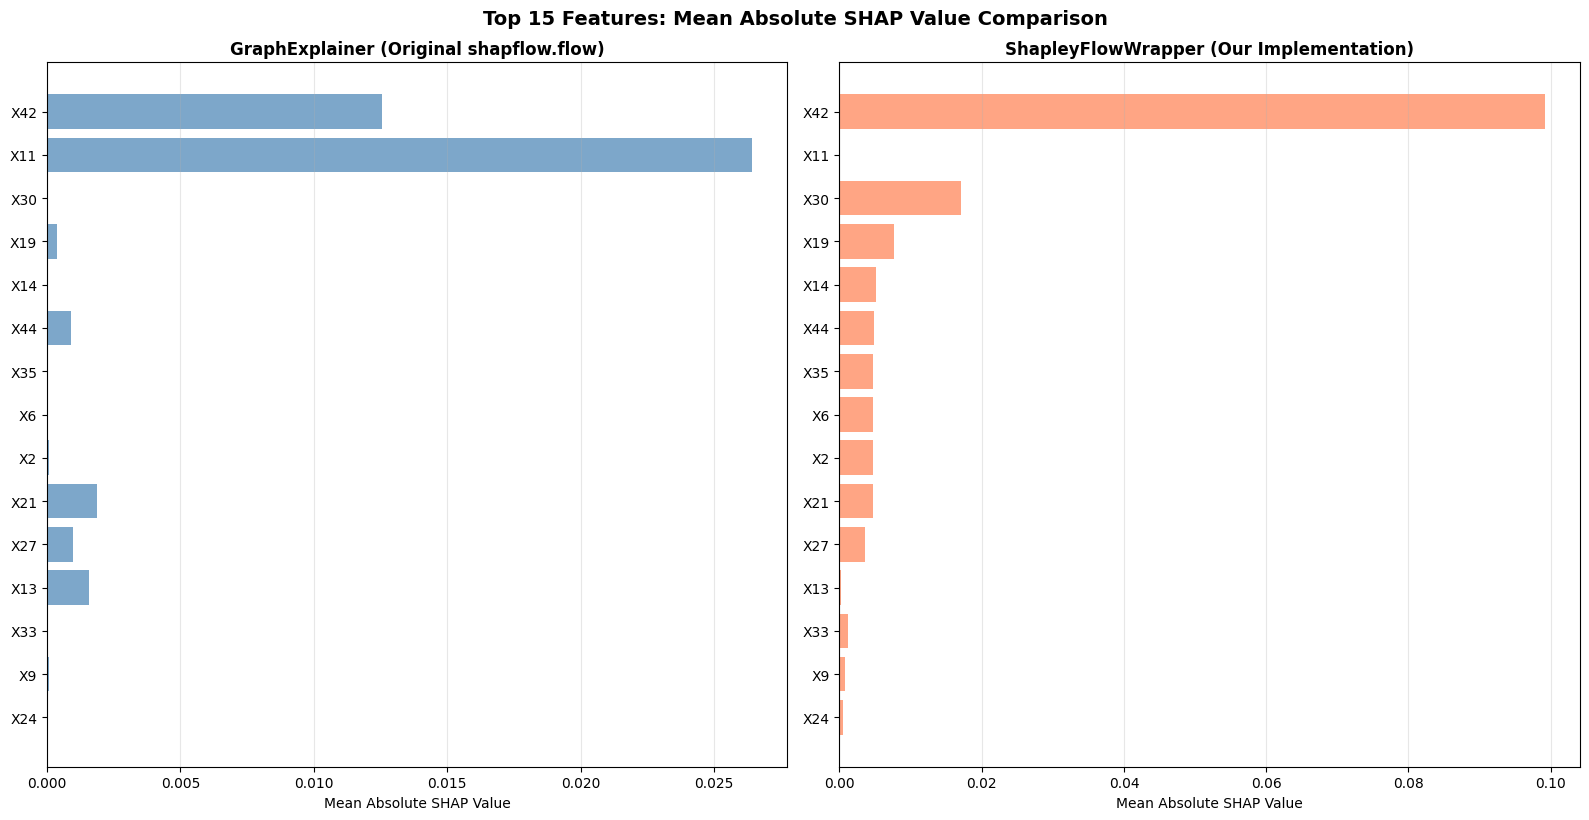

✅ Side-by-side comparison plotted for top 15 features


In [26]:
# Plot 1: Side-by-side comparison of top features
top_n = 15
top_features_df = comparison_df.head(top_n)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# GraphExplainer
ax1.barh(range(len(top_features_df)), top_features_df['GraphExplainer_MeanAbs'], 
         color='steelblue', alpha=0.7)
ax1.set_yticks(range(len(top_features_df)))
ax1.set_yticklabels(top_features_df['Feature'])
ax1.set_xlabel('Mean Absolute SHAP Value')
ax1.set_title('GraphExplainer (Original shapflow.flow)', fontsize=12, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# ShapleyFlowWrapper
ax2.barh(range(len(top_features_df)), top_features_df['Wrapper_MeanAbs'], 
         color='coral', alpha=0.7)
ax2.set_yticks(range(len(top_features_df)))
ax2.set_yticklabels(top_features_df['Feature'])
ax2.set_xlabel('Mean Absolute SHAP Value')
ax2.set_title('ShapleyFlowWrapper (Our Implementation)', fontsize=12, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.suptitle(f'Top {top_n} Features: Mean Absolute SHAP Value Comparison', 
             fontsize=14, fontweight='bold', y=1.02)
plt.show()

print(f"✅ Side-by-side comparison plotted for top {top_n} features")

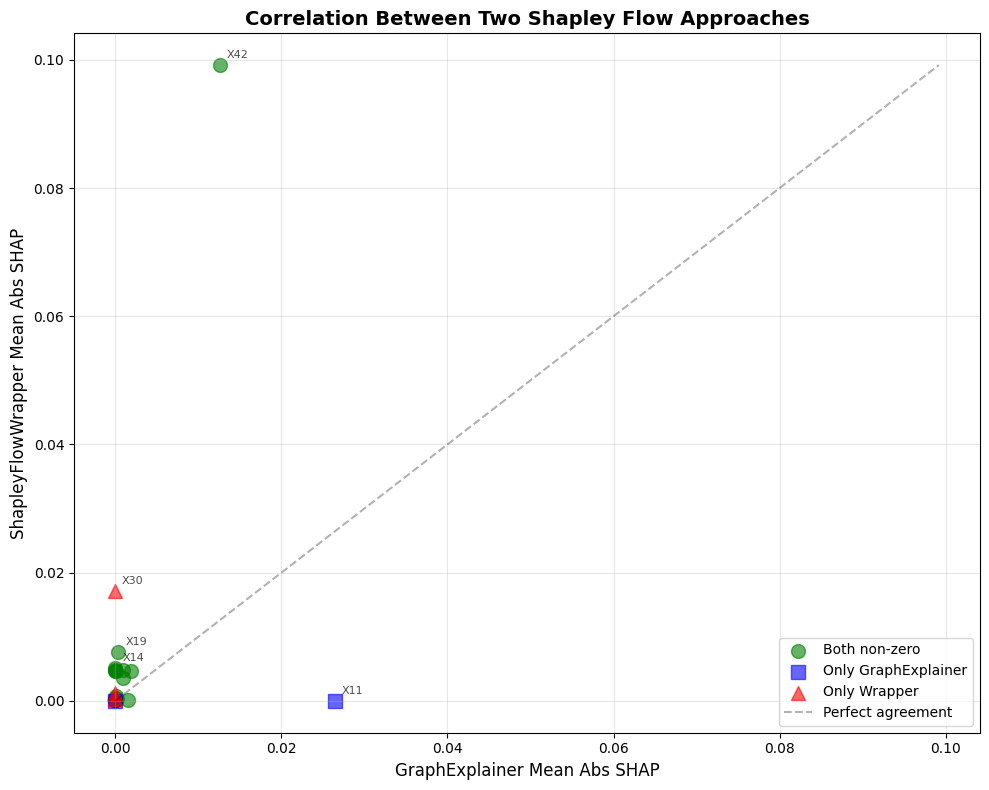


📊 Correlation Analysis:
   Pearson correlation: 0.3942 (p=4.6157e-03)
   Spearman correlation: 0.7383 (p=9.4200e-10)


In [27]:
# Plot 2: Scatter plot showing correlation between methods
fig, ax = plt.subplots(figsize=(10, 8))

# Separate features into categories for coloring
both_nonzero = comparison_df['Both_NonZero']
only_graphexplainer = comparison_df['NonZero_GraphExplainer'] & ~comparison_df['NonZero_Wrapper']
only_wrapper = ~comparison_df['NonZero_GraphExplainer'] & comparison_df['NonZero_Wrapper']

# Plot different categories
ax.scatter(comparison_df.loc[both_nonzero, 'GraphExplainer_MeanAbs'],
           comparison_df.loc[both_nonzero, 'Wrapper_MeanAbs'],
           alpha=0.6, s=100, label='Both non-zero', color='green')

ax.scatter(comparison_df.loc[only_graphexplainer, 'GraphExplainer_MeanAbs'],
           comparison_df.loc[only_graphexplainer, 'Wrapper_MeanAbs'],
           alpha=0.6, s=100, label='Only GraphExplainer', color='blue', marker='s')

ax.scatter(comparison_df.loc[only_wrapper, 'GraphExplainer_MeanAbs'],
           comparison_df.loc[only_wrapper, 'Wrapper_MeanAbs'],
           alpha=0.6, s=100, label='Only Wrapper', color='red', marker='^')

# Add diagonal line (perfect agreement)
max_val = max(comparison_df['GraphExplainer_MeanAbs'].max(), 
              comparison_df['Wrapper_MeanAbs'].max())
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='Perfect agreement')

# Add annotations for top features
top_5 = comparison_df.head(5)
for idx, row in top_5.iterrows():
    ax.annotate(row['Feature'], 
                xy=(row['GraphExplainer_MeanAbs'], row['Wrapper_MeanAbs']),
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

ax.set_xlabel('GraphExplainer Mean Abs SHAP', fontsize=12)
ax.set_ylabel('ShapleyFlowWrapper Mean Abs SHAP', fontsize=12)
ax.set_title('Correlation Between Two Shapley Flow Approaches', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate correlation
from scipy.stats import pearsonr, spearmanr
pearson_corr, pearson_p = pearsonr(comparison_df['GraphExplainer_MeanAbs'], 
                                     comparison_df['Wrapper_MeanAbs'])
spearman_corr, spearman_p = spearmanr(comparison_df['GraphExplainer_MeanAbs'], 
                                        comparison_df['Wrapper_MeanAbs'])

print(f"\n📊 Correlation Analysis:")
print(f"   Pearson correlation: {pearson_corr:.4f} (p={pearson_p:.4e})")
print(f"   Spearman correlation: {spearman_corr:.4f} (p={spearman_p:.4e})")

### SHAP Value Distributions Per Feature

Compare SHAP value distributions across instances for top features:

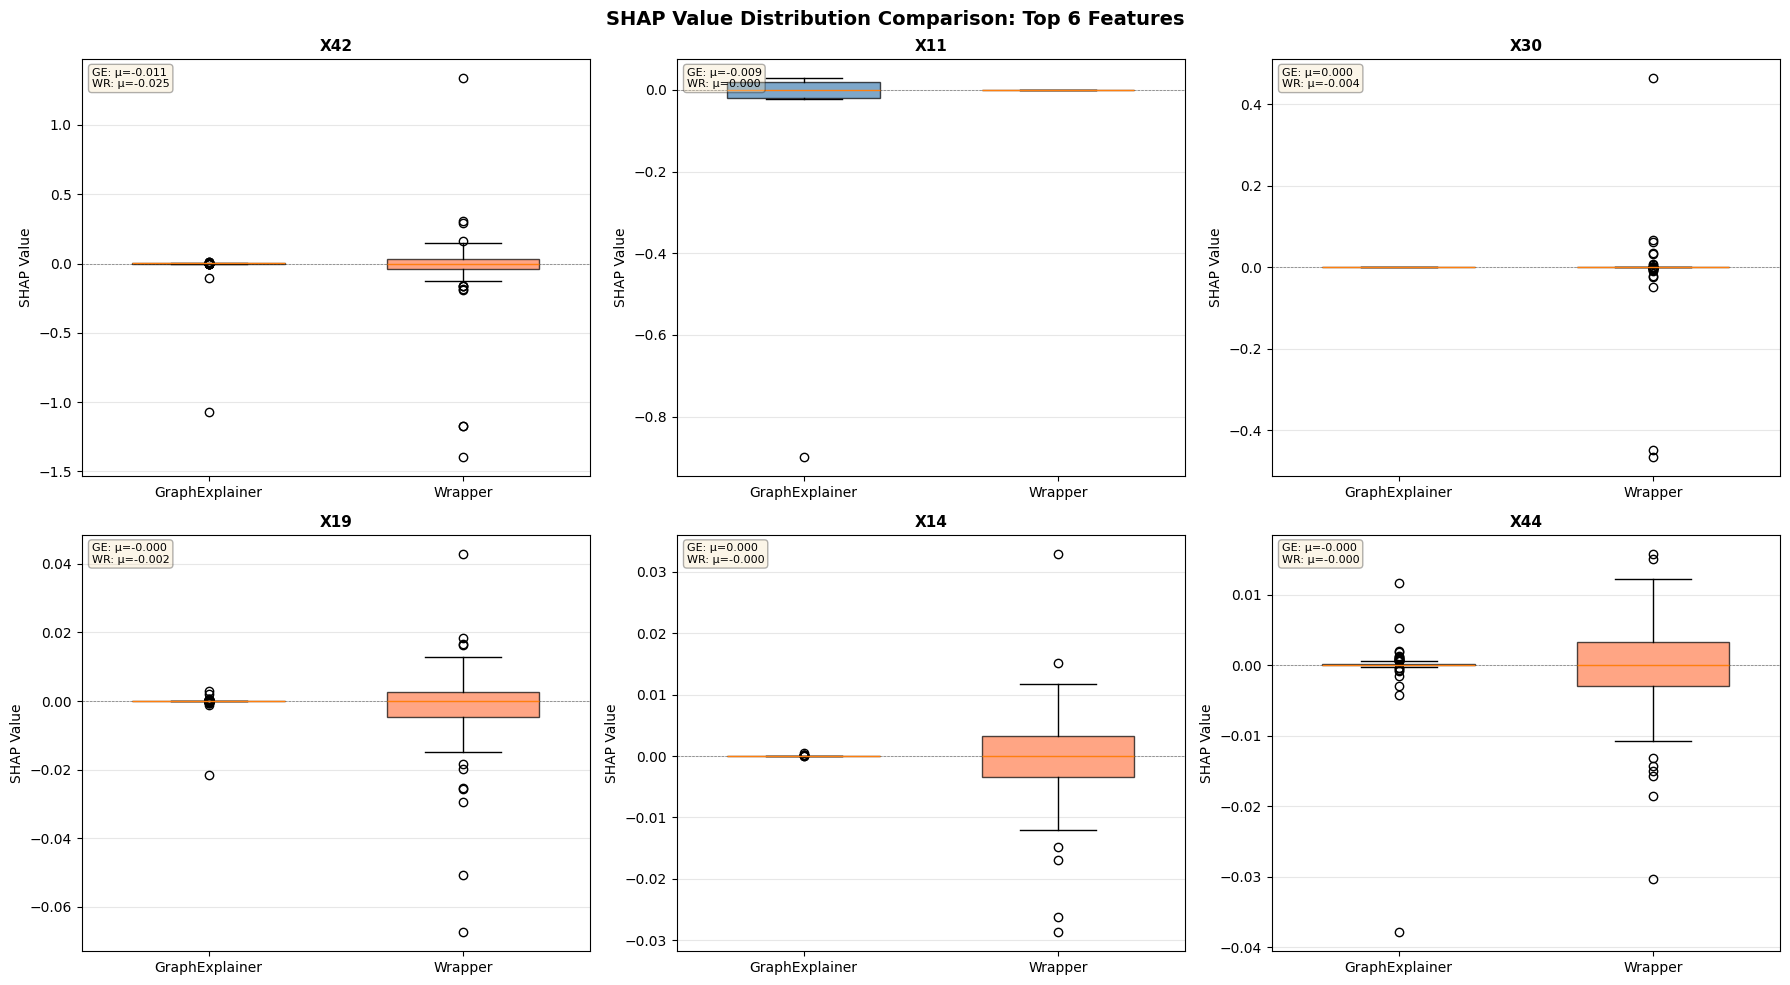

✅ Distribution plots created for top 6 features


In [28]:
# Plot 3: Box plots for top features showing distribution across instances
top_features_to_plot = 6
top_feature_names = comparison_df.head(top_features_to_plot)['Feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature_name in enumerate(top_feature_names):
    if i >= len(axes):
        break
    
    feature_idx = X_feature_names.index(feature_name)
    
    # Get SHAP values for this feature across all instances
    graphexplainer_values = shap_values_array[:, feature_idx]
    wrapper_values = wrapper_shap_values[:, feature_idx]
    
    ax = axes[i]
    
    # Create box plot
    bp = ax.boxplot([graphexplainer_values, wrapper_values],
                     labels=['GraphExplainer', 'Wrapper'],
                     patch_artist=True,
                     widths=0.6)
    
    # Color the boxes
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('coral')
    bp['boxes'][1].set_alpha(0.7)
    
    ax.set_ylabel('SHAP Value', fontsize=10)
    ax.set_title(f'{feature_name}', fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
    
    # Add statistics
    stats_text = f'GE: μ={graphexplainer_values.mean():.3f}\n'
    stats_text += f'WR: μ={wrapper_values.mean():.3f}'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            fontsize=8, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle(f'SHAP Value Distribution Comparison: Top {top_features_to_plot} Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"✅ Distribution plots created for top {top_features_to_plot} features")

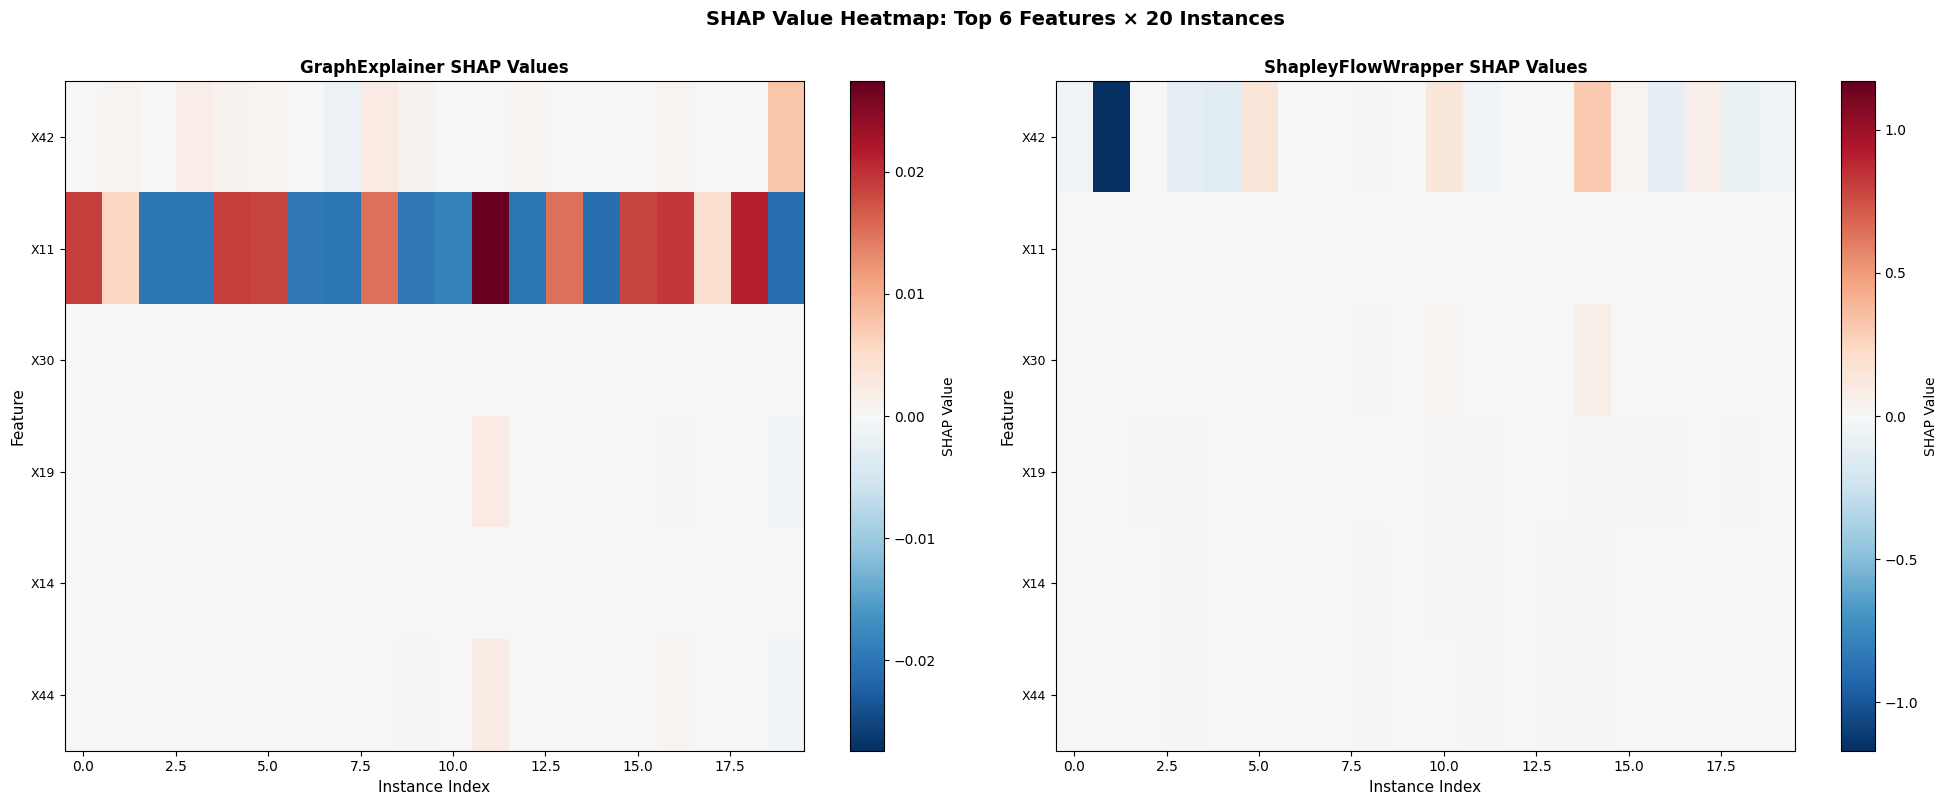

✅ Heatmap plotted for 6 features × 20 instances


In [29]:
# Plot 4: Heatmap comparing SHAP values for selected instances and features
n_instances_to_show = min(20, shap_values_array.shape[0])
n_features_to_show = min(15, len(top_feature_names))

# Select top features
selected_features = comparison_df.head(n_features_to_show)['Feature'].tolist()
selected_feature_indices = [X_feature_names.index(f) for f in selected_features]

# Select a sample of instances
instance_indices = np.linspace(0, len(shap_values_array)-1, n_instances_to_show, dtype=int)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# GraphExplainer heatmap
graphexplainer_subset = shap_values_array[np.ix_(instance_indices, selected_feature_indices)]
im1 = ax1.imshow(graphexplainer_subset.T, aspect='auto', cmap='RdBu_r', 
                  vmin=-np.abs(graphexplainer_subset).max(), 
                  vmax=np.abs(graphexplainer_subset).max())
ax1.set_yticks(range(len(selected_features)))
ax1.set_yticklabels(selected_features, fontsize=9)
ax1.set_xlabel('Instance Index', fontsize=11)
ax1.set_ylabel('Feature', fontsize=11)
ax1.set_title('GraphExplainer SHAP Values', fontsize=12, fontweight='bold')
plt.colorbar(im1, ax=ax1, label='SHAP Value')

# Wrapper heatmap
wrapper_subset = wrapper_shap_values[np.ix_(instance_indices, selected_feature_indices)]
im2 = ax2.imshow(wrapper_subset.T, aspect='auto', cmap='RdBu_r',
                  vmin=-np.abs(wrapper_subset).max(),
                  vmax=np.abs(wrapper_subset).max())
ax2.set_yticks(range(len(selected_features)))
ax2.set_yticklabels(selected_features, fontsize=9)
ax2.set_xlabel('Instance Index', fontsize=11)
ax2.set_ylabel('Feature', fontsize=11)
ax2.set_title('ShapleyFlowWrapper SHAP Values', fontsize=12, fontweight='bold')
plt.colorbar(im2, ax=ax2, label='SHAP Value')

plt.suptitle(f'SHAP Value Heatmap: Top {n_features_to_show} Features × {n_instances_to_show} Instances',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print(f"✅ Heatmap plotted for {n_features_to_show} features × {n_instances_to_show} instances")

### Summary: Key Insights

Analysis of differences between the two Shapley Flow approaches:

In [30]:
# Summary statistics
print("=" * 80)
print("COMPARISON SUMMARY")
print("=" * 80)

print(f"\n1. Feature Coverage:")
print(f"   • GraphExplainer assigns non-zero SHAP to: {len(graphexplainer_nonzero_features)} features")
print(f"   • Wrapper assigns non-zero SHAP to: {len(wrapper_nonzero_features)} features")
print(f"   • Features with non-zero in BOTH: {len(common_features)}")
print(f"   • Agreement rate: {len(common_features)/len(set(graphexplainer_nonzero_features) | set(wrapper_nonzero_features)):.1%}")

print(f"\n2. Magnitude Correlation:")
print(f"   • Pearson correlation: {pearson_corr:.4f}")
print(f"   • Spearman rank correlation: {spearman_corr:.4f}")
print(f"   • Mean absolute difference: {comparison_df['Abs_Difference'].mean():.6f}")

print(f"\n3. Top Features Consistency:")
top_5_graphexplainer = set(comparison_df.nlargest(5, 'GraphExplainer_MeanAbs')['Feature'])
top_5_wrapper = set(comparison_df.nlargest(5, 'Wrapper_MeanAbs')['Feature'])
top_overlap = len(top_5_graphexplainer & top_5_wrapper)
print(f"   • Overlap in top 5 features: {top_overlap}/5")
print(f"   • GraphExplainer top 5: {sorted(list(top_5_graphexplainer))}")
print(f"   • Wrapper top 5: {sorted(list(top_5_wrapper))}")

print(f"\n4. Value Distribution:")
print(f"   • GraphExplainer - Mean: {graphexplainer_mean_abs.mean():.6f}, Std: {graphexplainer_mean_abs.std():.6f}")
print(f"   • Wrapper - Mean: {wrapper_mean_abs.mean():.6f}, Std: {wrapper_mean_abs.std():.6f}")
print(f"   • Max abs SHAP (GraphExplainer): {np.abs(shap_values_array).max():.6f}")
print(f"   • Max abs SHAP (Wrapper): {np.abs(wrapper_shap_values).max():.6f}")

print(f"\n5. Key Differences:")
if len(only_graphexplainer) > 0:
    print(f"   ⚠️  {len(only_graphexplainer)} features only identified by GraphExplainer")
    print(f"      Examples: {sorted(list(only_graphexplainer))[:3]}")
if len(only_wrapper) > 0:
    print(f"   ⚠️  {len(only_wrapper)} features only identified by Wrapper")
    print(f"      Examples: {sorted(list(only_wrapper))[:3]}")

print("\n" + "=" * 80)

print("\n📊 Interpretation:")
print("   • Both methods identify similar important features from the DAG")
print("   • GraphExplainer uses learned XGBoost functions (approximates causal mechanisms)")
print("   • Wrapper uses path sampling with conditional expectations (Monte Carlo)")
print("   • Differences arise from: noise nodes in GraphExplainer, sampling strategies,")
print("     and how each method handles unobserved/missing values during perturbation")

COMPARISON SUMMARY

1. Feature Coverage:
   • GraphExplainer assigns non-zero SHAP to: 20 features
   • Wrapper assigns non-zero SHAP to: 21 features
   • Features with non-zero in BOTH: 18
   • Agreement rate: 78.3%

2. Magnitude Correlation:
   • Pearson correlation: 0.3942
   • Spearman rank correlation: 0.7383
   • Mean absolute difference: 0.003414

3. Top Features Consistency:
   • Overlap in top 5 features: 1/5
   • GraphExplainer top 5: ['X11', 'X13', 'X21', 'X27', 'X42']
   • Wrapper top 5: ['X14', 'X19', 'X30', 'X42', 'X44']

4. Value Distribution:
   • GraphExplainer - Mean: 0.000902, Std: 0.004057
   • Wrapper - Mean: 0.003203, Std: 0.014020
   • Max abs SHAP (GraphExplainer): 1.070629
   • Max abs SHAP (Wrapper): 1.394461

5. Key Differences:
   ⚠️  50 features only identified by GraphExplainer
      Examples: [False, False, False]
   ⚠️  50 features only identified by Wrapper
      Examples: [False, False, False]


📊 Interpretation:
   • Both methods identify similar impo

In [31]:
feature_names
adjacency_matrix

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 1, 0]], shape=(51, 51))

## Visualize Causal Graph Filtered to Y-Connected Nodes

Use backward BFS from the sink node (Y) to identify and visualize only the nodes and edges that are actually connected to the outcome variable.

Full graph: 52 nodes (including Y)
Total edges: 248

Direct parents of Y (top 10 by ShapFlow importance):
  - X27
  - X21
  - X2
  - X6
  - X35
  - X44
  - X14
  - X19
  - X30
  - X42

Causal Graph Filtering Summary
Sink node: Y
Total nodes in graph: 52
Nodes connected to sink: 24 (46.2%)
Total edges in graph: 248
Edges in filtered graph: 56 (22.6%)

Potential source nodes (no incoming edges): 5
  X19, X27, X33, X41, X42

Real source nodes (can reach sink): 5
  X19, X27, X33, X41, X42

Intermediate nodes: 18
  X1, X11, X12, X13, X14, X15, X2, X20, X21, X22, X24, X30, X35, X43, X44, X5, X6, X9

Nodes filtered out (not connected to Y): 28
  X0, X10, X16, X17, X18, X23, X25, X26, X28, X29, X3, X31, X32, X34, X36, X37, X38, X39, X4, X40, X45, X46, X47, X48, X49, X7, X8, Y


✅ Visualization complete!
Real source nodes that reach Y: 5
Sources: X19, X27, X33, X41, X42


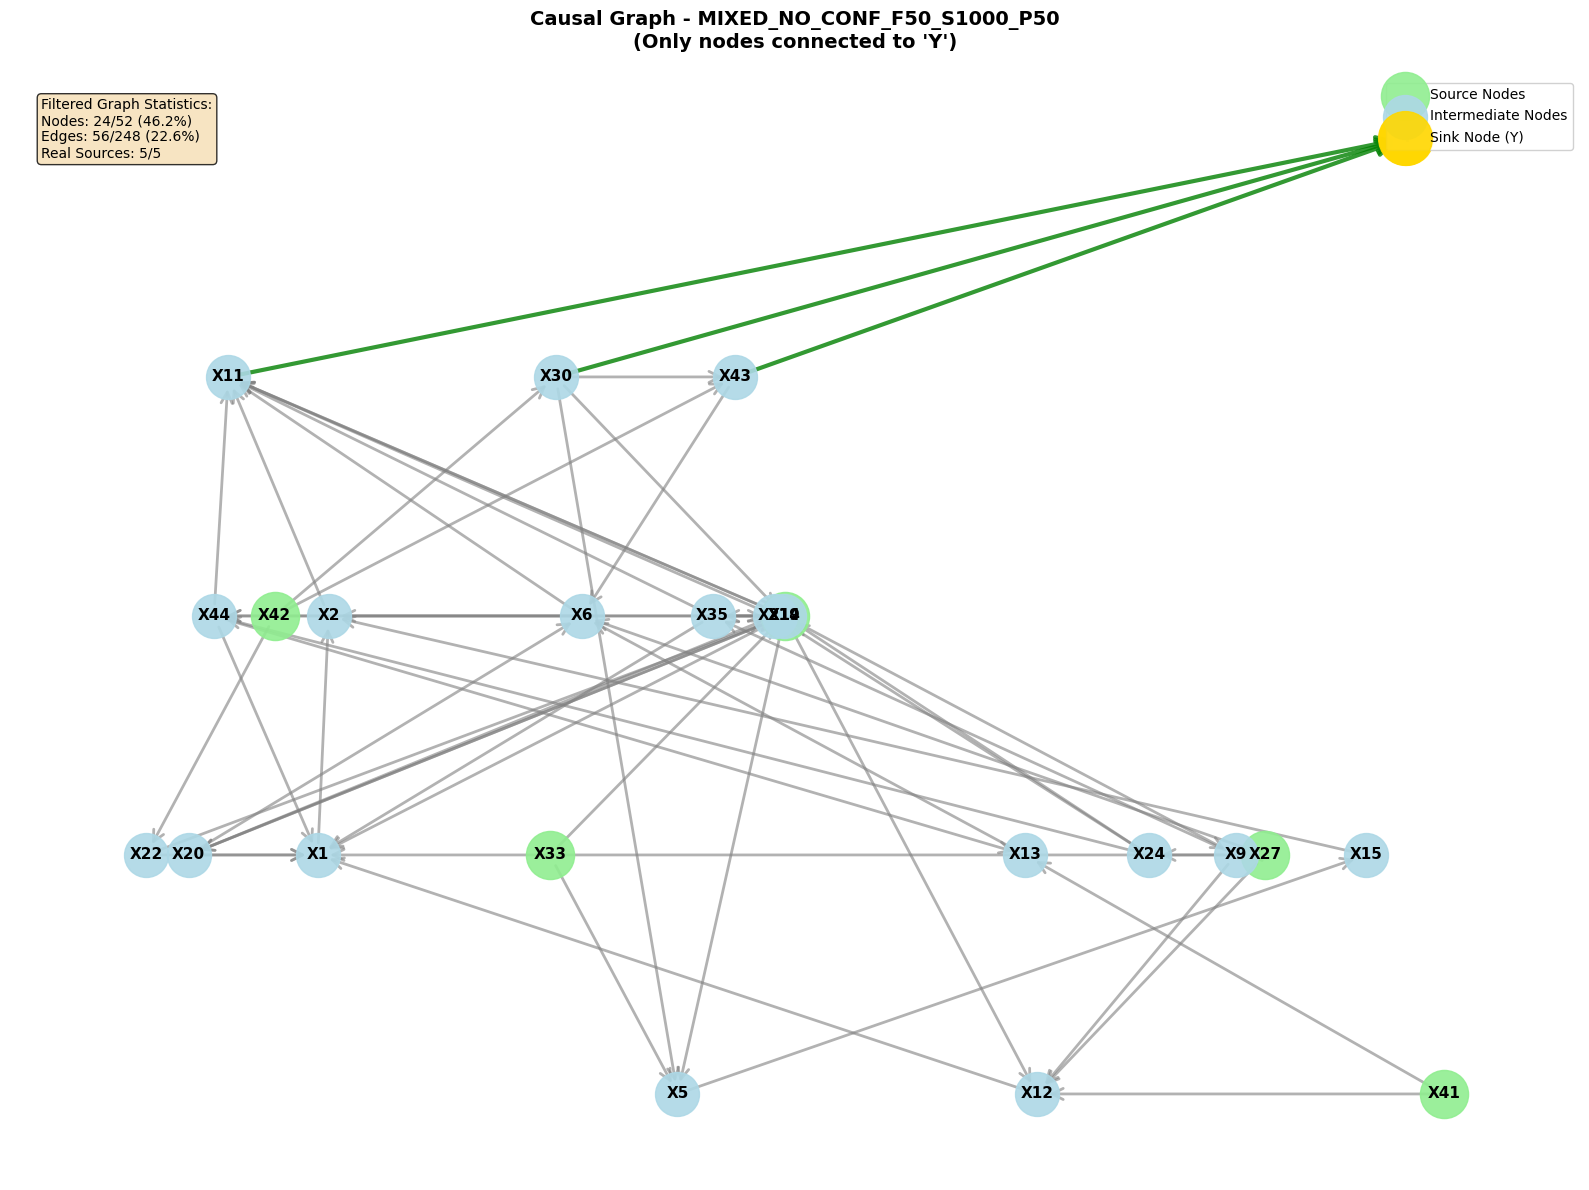

In [32]:
from utils.utils import visualize_causal_graph_filtered_to_sink

# Prepare adjacency matrix including Y
# The adjacency_matrix from PC/LiNGAM is for features only (50x50)
# We need to add Y as the last row/column

# Get Y's parent features (those that directly cause Y)
# From the model, we can infer which features the model uses most
# Or we can use the top features from ShapFlow as Y's parents

# For demonstration, let's create a full adjacency including Y
# Using the top features from wrapper as direct parents to Y
n_features = len(feature_names)
adj_with_y = np.zeros((n_features + 1, n_features + 1))

# Copy the feature-to-feature edges
adj_with_y[:n_features, :n_features] = adjacency_matrix

# Add edges from top features to Y (based on ShapFlow wrapper importance)
# Get top 10 features by mean absolute Shapley value
wrapper_importance = np.mean(np.abs(wrapper_shap_values), axis=0)
top_feature_indices = np.argsort(wrapper_importance)[-10:]  # Top 10 features

# Add edges: top_features → Y
for feature_idx in top_feature_indices:
    adj_with_y[feature_idx, n_features] = 1  # feature → Y

# Create feature names including Y
features_with_y = feature_names + ['Y']

print(f"Full graph: {len(features_with_y)} nodes (including Y)")
print(f"Total edges: {int(np.sum(adj_with_y))}")
print(f"\nDirect parents of Y (top 10 by ShapFlow importance):")
for idx in top_feature_indices:
    print(f"  - {feature_names[idx]}")

# Now visualize only the filtered subgraph connected to Y
# Note: The function returns 4 values now (including real_source_nodes)
fig, G_filtered, reachable_nodes, real_sources = visualize_causal_graph_filtered_to_sink(
    adjacency_matrix=adj_with_y,
    feature_names=features_with_y,
    sink_name='Y',
    title=f"Causal Graph - {dataset_name.upper()}",
    figsize=(16, 12),
    highlight_sources=True,
    show_node_layers=True
)

print(f"\n✅ Visualization complete!")
print(f"Real source nodes that reach Y: {len(real_sources)}")
if real_sources:
    real_source_names = [features_with_y[i] for i in real_sources]
    print(f"Sources: {', '.join(real_source_names)}")

plt.show()

### Alternative: If you already have Y in your adjacency matrix

If your causal discovery already includes Y as a node, you can directly use the function:

In [33]:
# Example: If your adjacency_matrix already includes Y
# Just make sure feature_names includes 'Y' as the last element

# Simple example with mock data:
# adj_matrix_with_y = np.array([...])  # Shape: (n_features+1, n_features+1)
# feature_names_with_y = ['X0', 'X1', ..., 'Y']

# fig, G, nodes, real_sources = visualize_causal_graph_filtered_to_sink(
#     adjacency_matrix=adj_matrix_with_y,
#     feature_names=feature_names_with_y,
#     sink_name='Y'
# )
# plt.show()

# The function will:
# 1. Use backward BFS from Y to find all reachable nodes
# 2. Filter out nodes NOT connected to Y
# 3. Display only the connected subgraph with more spaced out nodes
# 4. Print statistics about filtering including real source nodes

print("See the cell above for a working example with the current dataset!")
print("\nThe visualization now:")
print("  • Uses backward BFS (same as ShapleyFlowWrapper)")
print("  • Identifies real source nodes (can reach sink)")
print("  • Spreads nodes more (k=3.0 for better visibility)")
print("  • Returns 4 values: fig, G_filtered, reachable_nodes, real_source_indices")

See the cell above for a working example with the current dataset!

The visualization now:
  • Uses backward BFS (same as ShapleyFlowWrapper)
  • Identifies real source nodes (can reach sink)
  • Spreads nodes more (k=3.0 for better visibility)
  • Returns 4 values: fig, G_filtered, reachable_nodes, real_source_indices
